In [1]:
import os
import xarray as xr
import numpy as np

import bed

2024-04-25 14:31:57,162 - INFO - logging started at: 2024-04-25


In [2]:
bed.__version__

'0.0.0'

In [3]:
# Get example data (uncomment if not yet downloaded)
# data_folder = bed.get_data()
data_folder = '../downloaded_data/examples/'

In [4]:
config_file = os.path.join(data_folder, "example_config.yml")

In [10]:
example_bed = bed.Bed(config_file)

2024-04-25 14:32:25,954 - INFO - Starting class Data inside module read_data...
2024-04-25 14:32:25,955 - INFO - Starting function read_config...
2024-04-25 14:32:25,958 - INFO - Function read_config complete.
2024-04-25 14:32:25,959 - INFO - Reading temperature_data data
2024-04-25 14:32:25,984 - INFO - Reading building_area_data data
2024-04-25 14:32:26,010 - INFO - Reading building_height_data data
2024-04-25 14:32:26,033 - INFO - Calculating surface area to floor space ratio
2024-04-25 14:32:26,047 - INFO - Class Data inside module read_data completed.
2024-04-25 14:32:26,048 - INFO - Starting function temperature_to_degree_hours.
2024-04-25 14:32:26,079 - INFO - Function temperature_to_degree_hours completed.
2024-04-25 14:32:26,080 - INFO - Starting function demand.
2024-04-25 14:32:26,124 - INFO - Function demand completed.
2024-04-25 14:32:26,124 - INFO - Plotting diagnostics for temperature data...
2024-04-25 14:32:26,370 - INFO - Diagnostic plots saved to: /Users/prim232/gitr

In [6]:
hdd_data = -1 * (example_bed.data.temperature - 291.483)
hdd_data = hdd_data.where(hdd_data > 0, 0)
hdd_data = hdd_data.integrate('time', datetime_unit='h')

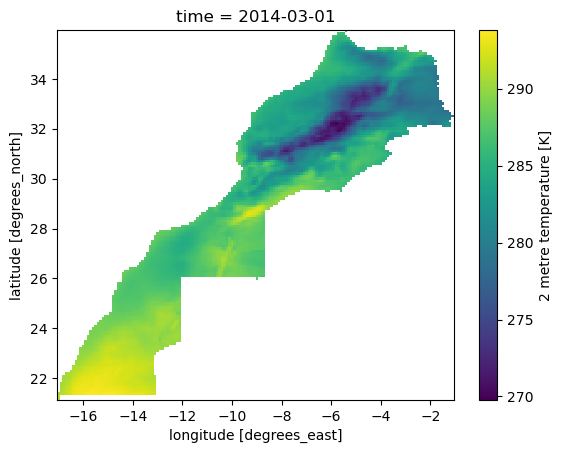

In [7]:
example_bed.data.temperature['t2m'].isel(time=0).plot()

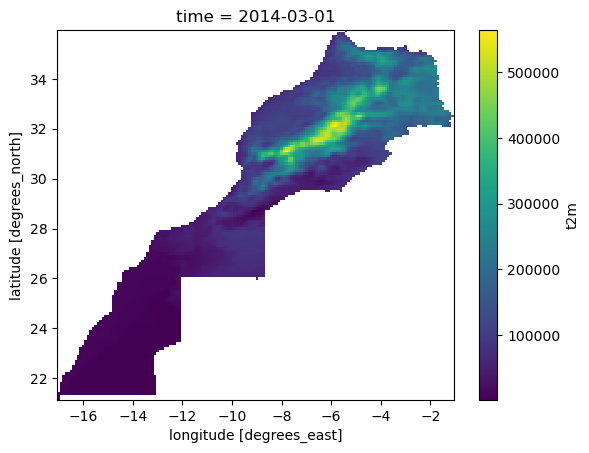

In [8]:
hdd_data.where(~np.isnan(example_bed.data.temperature.isel(time=0)))['t2m'].plot()